In [1]:
import pandas as pd

#data collection and check
df=pd.read_csv("diabetes.csv")
#print(df.head())
#df.shape
#df.dtypes
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [2]:
import matplotlib.pyplot as plt
import seaborn as sb
plt.style.use("ggplot")

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64


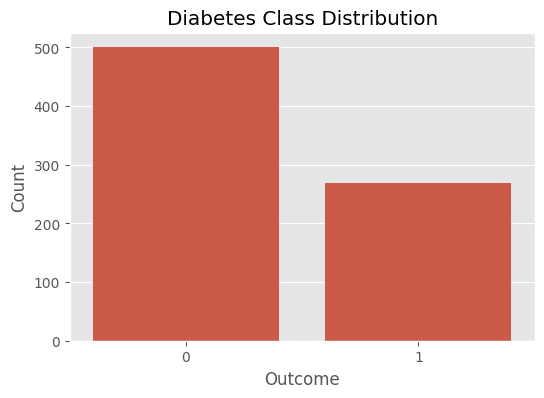

In [3]:
df["Outcome"].value_counts()
plt.figure(figsize=(6,4))
sb.countplot(x=df["Outcome"])
plt.title("Diabetes Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
corr=df.corr(numeric_only=True)["Outcome"]
print(corr)
plt.show()

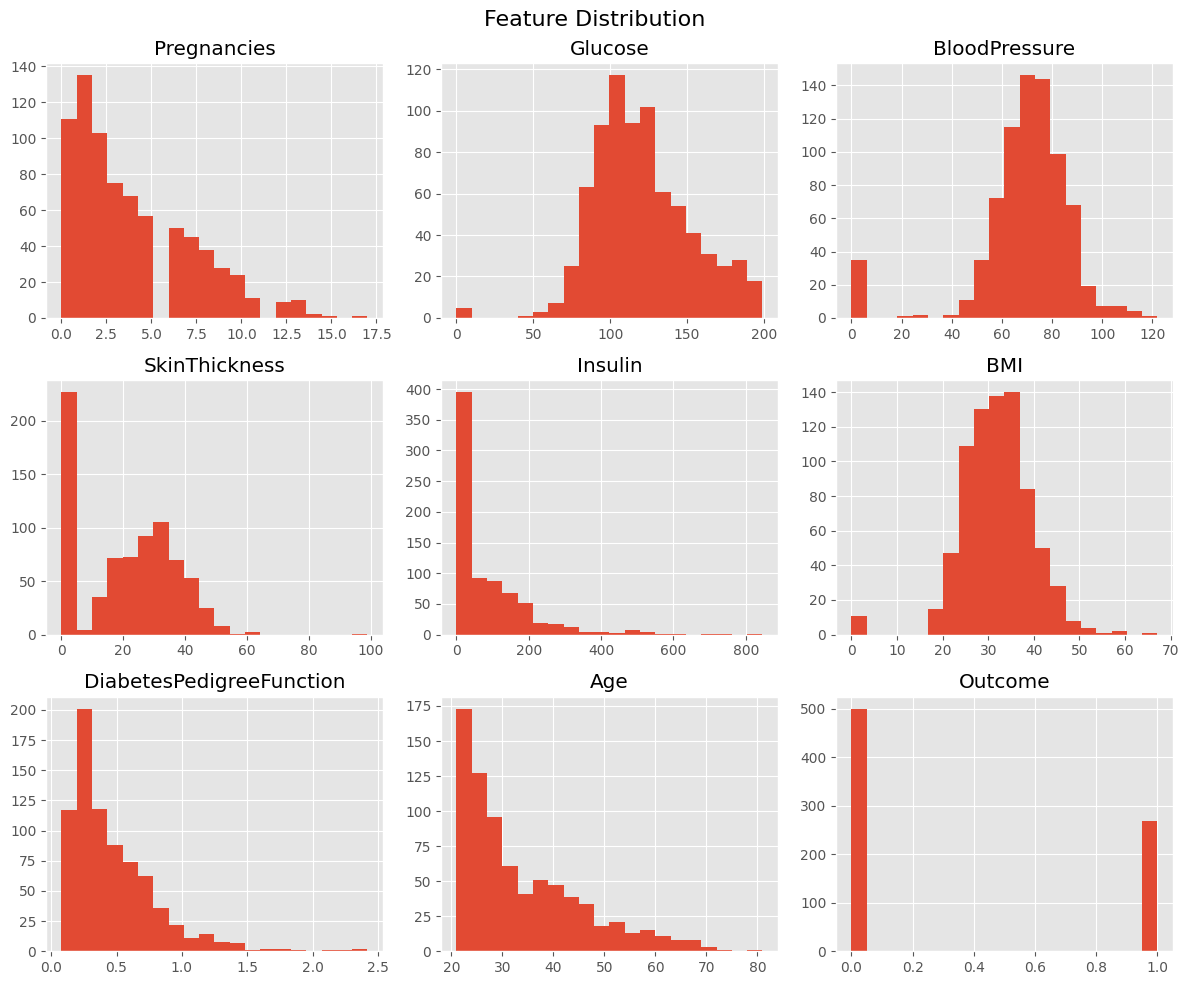

In [4]:
#histograms for all fiture
df.hist(figsize=(12,10),bins=20)
plt.suptitle("Feature Distribution",fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
#data processing
X=df.drop("Outcome",axis=1)
y=df["Outcome"]


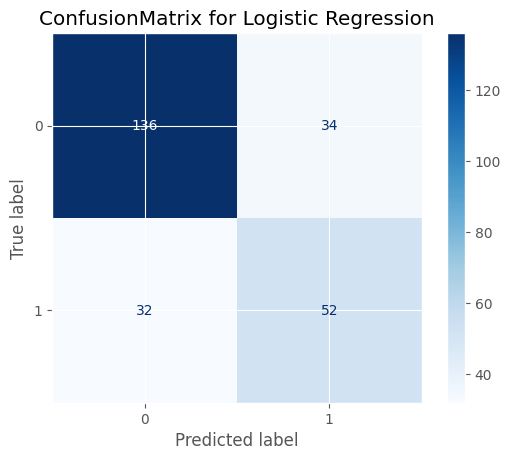

In [6]:
#Train-Test split and Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,confusion_matrix,ConfusionMatrixDisplay,precision_score,recall_score,f1_score,roc_auc_score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.33, random_state=42)
model_LR=LogisticRegression()
model_LR.fit(X_train,y_train)
y_pred_LR=model_LR.predict(X_test)
acc_LR=accuracy_score(y_pred_LR,y_test)
pre_LR=precision_score(y_pred_LR,y_test)
recall_LR=recall_score(y_pred_LR,y_test)
f1_LR=f1_score(y_pred_LR,y_test)
roc_LR=roc_auc_score(y_pred_LR,y_test)
cm_LR=confusion_matrix(y_pred_LR,y_test)
disp_LR=ConfusionMatrixDisplay(confusion_matrix=cm_LR)
disp_LR.plot(cmap="Blues")
plt.title("ConfusionMatrix for Logistic Regression")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

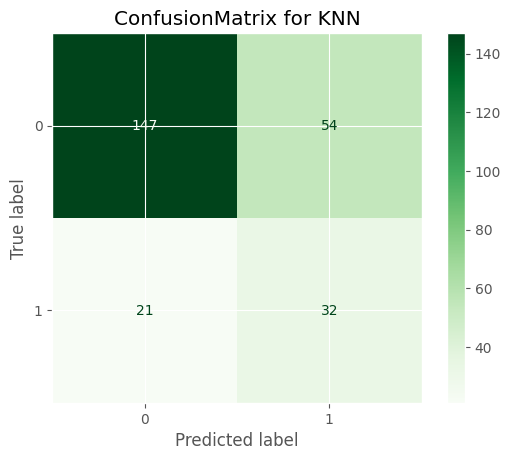

In [7]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
model_KNN=KNeighborsClassifier(n_neighbors=4)
model_KNN.fit(X_train,y_train)
y_pred_KNN=model_KNN.predict(X_test)
acc_KNN=accuracy_score(y_pred_KNN,y_test)
pre_KNN=precision_score(y_pred_KNN,y_test)
recall_KNN=recall_score(y_pred_KNN,y_test)
f1_KNN=f1_score(y_pred_KNN,y_test)
cm_KNN=confusion_matrix(y_pred_KNN,y_test)
roc_KNN=roc_auc_score(y_pred_KNN,y_test)

disp_KNN=ConfusionMatrixDisplay(confusion_matrix=cm_KNN)
disp_KNN.plot(cmap="Greens")
plt.title("ConfusionMatrix for KNN")
plt.show


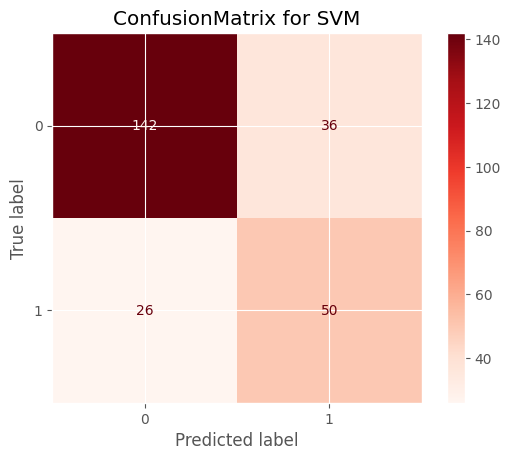

In [8]:
#SVM
from sklearn.svm import SVC
model_SVM=SVC()
model_SVM.fit(X_train,y_train)
y_pred_SVM=model_SVM.predict(X_test)
acc_SVM=accuracy_score(y_pred_SVM,y_test)
pre_SVM=precision_score(y_pred_SVM,y_test)
recall_SVM=recall_score(y_pred_SVM,y_test)
f1_SVM=f1_score(y_pred_SVM,y_test)
cm_SVM=confusion_matrix(y_pred_SVM,y_test)
roc_SVM=roc_auc_score(y_pred_SVM,y_test)

disp_SVM=ConfusionMatrixDisplay(confusion_matrix=cm_SVM)
disp_SVM.plot(cmap="Reds")
plt.title("ConfusionMatrix for SVM")
plt.show()

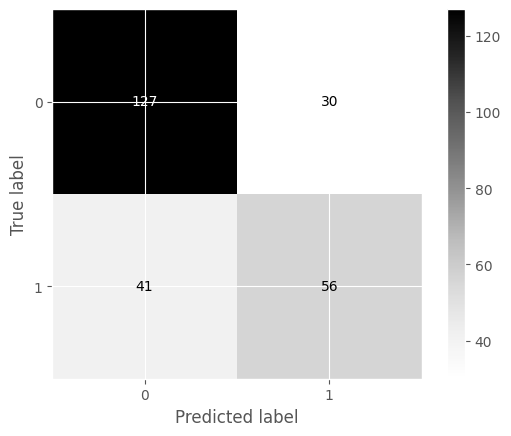

In [9]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
model_DT=DecisionTreeClassifier()
model_DT.fit(X_train,y_train)
y_pred_DT=model_DT.predict(X_test)
acc_DT=accuracy_score(y_pred_DT,y_test)
pre_DT=precision_score(y_pred_DT,y_test)
f1_DT=f1_score(y_pred_DT,y_test)
recall_DT=recall_score(y_pred_DT,y_test)
cm_DT=confusion_matrix(y_pred_DT,y_test)
roc_DT=roc_auc_score(y_pred_DT,y_test)

disp_DT=ConfusionMatrixDisplay(confusion_matrix=cm_DT)
disp_DT.plot(cmap="Grays")
plt.show()

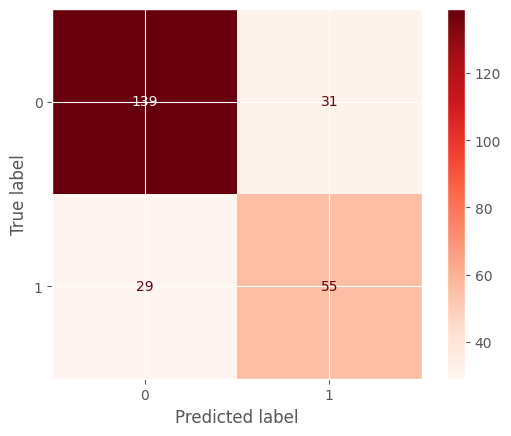

0.7637795275590551

In [10]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
model_RF=RandomForestClassifier()
model_RF.fit(X_train,y_train)
y_pred_RF=model_RF.predict(X_test)
acc_RF=accuracy_score(y_pred_RF,y_test)
pre_RF=precision_score(y_pred_RF,y_test)
f1_RF=f1_score(y_pred_RF,y_test)
recall_RF=recall_score(y_pred_RF,y_test)
cm_RF=confusion_matrix(y_pred_RF,y_test)
roc_RF=roc_auc_score(y_pred_RF,y_test)

disp_RF=ConfusionMatrixDisplay(confusion_matrix=cm_RF)
disp_RF.plot(cmap="Reds")
plt.show()

acc_RF

In [11]:
#Createing a Result dataFrame 
result=pd.DataFrame(
    {
        "Model":[
            "LogisticRegression","KNN","SVM","Decision Tree","Random Forest"
        ],
        "Accuracy":[
            acc_LR,acc_KNN,acc_SVM,acc_DT,acc_RF
        ],
        "f1_score":[
            f1_LR,f1_KNN,f1_SVM,f1_DT,f1_RF
        ],
        "recall_score":[
            recall_DT,recall_KNN,recall_SVM,recall_DT,recall_RF
        ],
        "roc_auc_score":[
            roc_LR,roc_KNN,roc_SVM,roc_DT,roc_RF
        ],
        "confusion_matrix":[
            cm_LR,cm_KNN,cm_SVM,cm_DT,cm_RF
        ]
    }
)
result

,Model,Accuracy,f1_score,recall_score,roc_auc_score,confusion_matrix
0,LogisticRegression,0.740157,0.611765,0.577320,0.709524,"[[136, 34], [32, 52]]"
1,KNN,0.704724,0.460432,0.603774,0.667558,"[[147, 54], [21, 32]]"
2,SVM,0.755906,0.617284,0.657895,0.727824,"[[142, 36], [26, 50]]"
3,Decision Tree,0.720472,0.612022,0.577320,0.693118,"[[127, 30], [41, 56]]"
4,Random Forest,0.763780,0.647059,0.654762,0.736204,"[[139, 31], [29, 55]]"


In [12]:
#create file for users
import joblib
joblib.dump(model_LR,"model_LR.pkl")
joblib.dump(model_KNN,"model_KNN.pkl")
joblib.dump(model_SVM,"model_SVM.pkl")
joblib.dump(model_DT,"model_DT.pkl")
joblib.dump(model_RF,"model_RF.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']